# Import

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sqpulse import (
    GaussianPulse,
    CosinePulse,
    LorentzianPulse,
    SquarePulse,
    FlatTopPulse,
    DRAGPulse,
    SechPulse,
    SlepianPulse,
    NetZeroPulse,
    CosineHD2DRAGPulse,
    PhaseModulatedSinPulse,
    IdlePulse,
    CustomPulse,
    compare_pulses,
    spectral_leakage,
    Transmon,
    PulseSequence,
    Simulator,
    RabiExperiment,
    T1Experiment,
    RamseyExperiment,
)

from sqpulse.experiments import QubitSpectroscopyExperiment

# 一、脉冲波形与时频域特征分析

In [ ]:
p_gauss = GaussianPulse(duration=40e-9, amp=0.8, chop=6.0, drag=0, name="Gaussian")
fig = p_gauss.plot(domain="both")

In [ ]:
p_cos = CosinePulse(duration=40e-9, amp=1.0, drag=0, detune=0.0, name="Cosine (Hann)")
fig = p_cos.plot(domain="both")

In [ ]:
p_lorentz = LorentzianPulse(duration=40e-9, amp=1.0, gamma=10e-9, name="Lorentzian")
fig = p_lorentz.plot(domain="both")

In [ ]:
p_square = SquarePulse(duration=40e-9, amp=1.0, name="Square")
fig = p_square.plot(domain="both")

In [ ]:
p_flattop = FlatTopPulse(duration=40.0e-9, amp=1.0, ramp_time=4e-9, ramp_type="gaussian", name="FlatTop (Gaussian)")
fig = p_flattop.plot(domain="both")

In [ ]:
p_flattop_os = FlatTopPulse(
    duration=60e-9,
    amp=0.8,
    ramp_time=15e-9,
    ramp_type="tanh",
    # overshoot_amp=0.2,
    # overshoot_len=10e-9,
    name="FlatTop (Tanh+Overshoot)",
)
fig = p_flattop_os.plot(domain="both")

In [ ]:
p_drag = DRAGPulse(duration=40e-9, amp=1.0, drag=1, sigma=8e-9, name="Gaussian+DRAG")
fig = p_drag.plot(domain="both")

In [ ]:
p_hd2 = CosineHD2DRAGPulse(
    duration=20e-9,
    amp=1.0,
    alpha=-250e6,
    f_suppress=90e6,
    name="Cosine HD-DRAG",
)
fig = p_hd2.plot(domain="both")

In [ ]:
p_sech = SechPulse(duration=40e-9, amp=0.8, sigma=10e-9, name="Sech")
fig = p_sech.plot(domain="both")

In [ ]:
p_slepian = SlepianPulse(duration=40e-9, amp=0.8, nw=3.0, name="Slepian (DPSS)")
fig = p_slepian.plot(domain="both")

In [ ]:
p_netzero = NetZeroPulse(duration=60e-9, amp=0.8, ramp_type="erf", name="Net-Zero Flux")
fig = p_netzero.plot(domain="both")

In [ ]:
p_pm = PhaseModulatedSinPulse(duration=600e-9, amp=0.8, mod_freq=50e6, name="Phase-Modulated Sin")
fig = p_pm.plot(domain="both")

In [ ]:
p_idle = IdlePulse(duration=40e-9, name="Idle")
fig = p_idle.plot(domain="both")

In [ ]:
p_custom = CustomPulse(
    duration=40e-9,
    envelope_fn=lambda t: np.sin(np.pi * t / 40e-9) ** 4,
    name="Custom (Sin^4)",
)
fig = p_custom.plot(domain="both")

In [ ]:
fig_comp = compare_pulses(
    [p_gauss, p_cos, p_lorentz, p_sech, p_slepian],
    domain="both",
    dt=0.1e-9,
    freq_range=(-300e6, 300e6),
)

In [ ]:
# 计算 100 MHz 外的高频谱泄露比例
cutoff = 100e6
print(f"方波脉冲谱泄露 (>100 MHz):     {spectral_leakage(p_square, cutoff):.6f}")
print(f"洛伦兹脉冲谱泄露 (>100 MHz):   {spectral_leakage(p_lorentz, cutoff):.6f}")
print(f"高斯脉冲谱泄露 (>100 MHz):     {spectral_leakage(p_gauss, cutoff):.6f}")
print(f"余弦脉冲谱泄露 (>100 MHz):     {spectral_leakage(p_cos, cutoff):.6f}")
print(f"Sech脉冲谱泄露 (>100 MHz):     {spectral_leakage(p_sech, cutoff):.6f}")
print(f"Slepian脉冲谱泄露 (>100 MHz):  {spectral_leakage(p_slepian, cutoff):.6f}")

# 二、Transmon 物理模型与演化

## Qubit Evolution

### Setup model

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sqpulse import Transmon, ReadoutResonator, PulseSequence, GaussianPulse, FlatTopPulse, Measurement, ns, us, MHz, GHz

# 1. 定义通用 Transmon (支持结不对称度 d; d=1.0 为单结, d=0.2 为可调 SQUID)
q = Transmon("q0", f_q=5.0 * GHz, alpha=-250.0 * MHz, d=0.2, levels=3, t1=25.0 * us, t2=30.0 * us)

# 2. 编排多通道脉冲序列 (包含 XY 驱动、Z 磁通调频与腔读出)
seq = PulseSequence(name="control_and_readout")
# (1) 在 xy (XY) 施加 pi/2 脉冲
seq.add(q.xy, GaussianPulse(duration=30 * ns, amp=0.5))
seq.sync()

# (2) 在 z (Z) 施加快速磁通脉冲调制频率
seq.add(q.z, FlatTopPulse(duration=40 * ns, amp=0.1, ramp_time=4 * ns))
seq.sync()

# (3) 施加第二个 pi/2 脉冲
seq.add(q.xy, GaussianPulse(duration=30 * ns, amp=0.5))
seq.sync()

# (4) 在 ro (RO) 施加 1 us 微波读出脉冲
seq.add(q.ro, FlatTopPulse(duration=1000 * ns, amp=1.0, ramp_time=20 * ns))

# 绘制多通道时间轴对齐图
seq.plot()
plt.show()

### Backend: Projective

In [ ]:
# 3. 双后端测量选择
# 方式 A：选择理想投影与态演化后端 (精确主方程求解)
res_proj = Measurement.run(q, seq, backend="projective")
res_proj.plot_populations()
plt.show()

### Backend: Dispersive

In [ ]:
# 方式 B：选择真实色散谐振腔读出后端 (微波传输谱、IQ 解调与单次判决)
cavity = ReadoutResonator(name="r0", f_r=7.0 * GHz, kappa=2.0 * np.pi * 3.0 * MHz, chi=2.0 * np.pi * 1.5 * MHz)
res_disp = Measurement.run(q, seq, backend="dispersive", resonator=cavity, shots=1000, snr_db=15.0)
res_disp.plot_iq_plane()     # 查看 IQ 平面聚类散点图与判决面
res_disp.plot_trajectories() # 查看腔内光子动力学建立与衰减
plt.show()
print(f"读出保真度: {res_disp.fidelity:.2%}")
print("混淆矩阵:\n", res_disp.confusion_matrix)

## Qubit Spectroscopy

### Setup model

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sqpulse import Transmon, PulseSequence, FlatTopPulse, PhaseModulatedSinPulse, Simulator, ns, us, MHz, GHz

# 1. 定义可调 SQUID Transmon (结不对称度 d=0.25 < 1.0)
q = Transmon(
    name="q0",
    f_q=5.0 * GHz,        # 对称点 (Sweet Spot, Phi=0) 跃迁频率
    alpha=-250.0 * MHz,   # 非谐性
    d=0.25,               # 结不对称度 (d < 1.0 为磁通可调 Transmon)
    levels=3,             # 截断能级 (|0>, |1>, |2>)
    t1=30.0 * us,
    t2=20.0 * us,
)

print(f"Sweet Spot 静态频率 f_q(0): {q.frequency_at_flux(0.0) / 1e9:.3f} GHz")

Sweet Spot 静态频率 f_q(0): 5.000 GHz


### Setup pulse sequence

Theoretical shifted frequency: 4.726 GHz


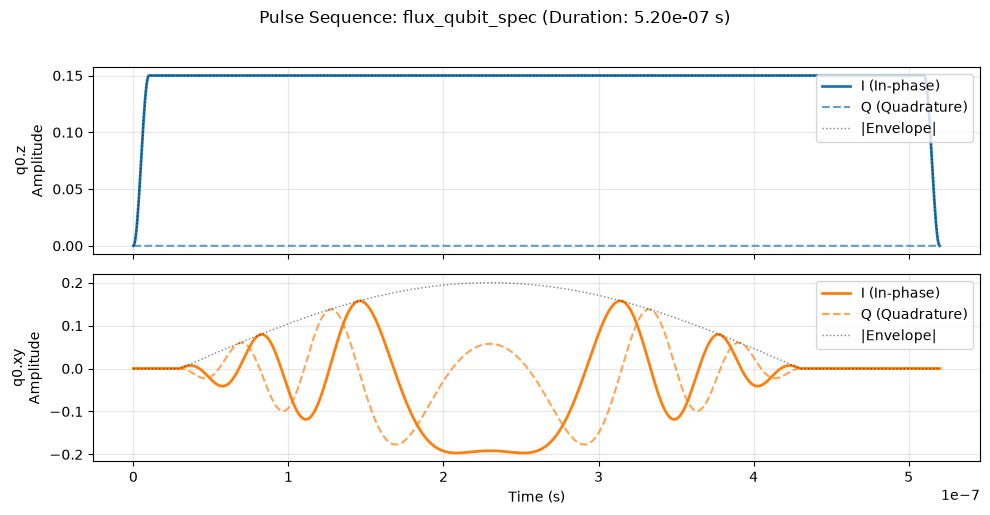

In [13]:
# 2. 构造多通道联合脉冲时序：Z 偏置脉冲 + 同步 XY 微波弱探测脉冲
phi_bias = 0.15                           # 目标 Z 偏置幅度 (单位: Phi_0)
f_shifted = q.frequency_at_flux(phi_bias) # 理论移动后跃迁频率 ~4.726 GHz
print(f"Theoretical shifted frequency: {f_shifted / 1e9:.3f} GHz")

# (1) 在 Z 偏置线施加 120 ns 平顶磁通脉冲 (上升/下降沿各 10 ns)
z_pulse = FlatTopPulse(duration=520 * ns, amp=phi_bias, ramp_time=10 * ns)

# (2) 在 XY 控制线施加 100 ns 弱微波探测脉冲 (延时 10 ns 对齐至 Z 脉冲平顶稳定阶段)
# xy_probe = FlatTopPulse(duration=100 * ns, amp=0.04, ramp_time=5 * ns)
xy_probe = PhaseModulatedSinPulse(duration=400e-9, amp=0.2, mod_freq=20e6, name="Phase-Modulated Sin")

seq = PulseSequence(name="flux_qubit_spec")
seq.add(q.z, z_pulse)
seq.delay(q.xy, 30 * ns)
seq.add(q.xy, xy_probe)

seq.plot()
plt.show()

### 1D Spectrum

理论目标跃迁频率: 4.7256 GHz
微波扫描共振峰值: 4.7376 GHz (峰值激发态布居 P1 = 0.991)


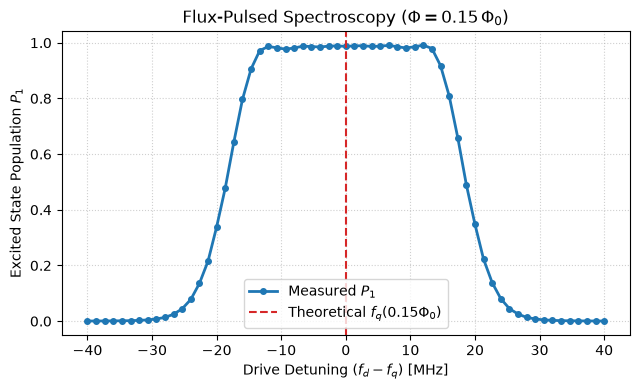

In [14]:
# 3. 扫描 XY 驱动载波频率 f_d
freqs = np.linspace(f_shifted - 40 * MHz, f_shifted + 40 * MHz, 61)
p1_vals = []

for fd in freqs:
    # 模拟驱动载波频率为 fd 时的含时哈密顿量动力学演化
    res = Simulator.run(q, seq, dt=1.0 * ns, f_d=float(fd))
    p1_vals.append(res.final_population(1))

p1_vals = np.array(p1_vals)
f_peak = freqs[np.argmax(p1_vals)]

print(f"理论目标跃迁频率: {f_shifted / 1e9:.4f} GHz")
print(f"微波扫描共振峰值: {f_peak / 1e9:.4f} GHz (峰值激发态布居 P1 = {np.max(p1_vals):.3f})")

# 4. 绘制 1D 频谱响应
plt.figure(figsize=(6.5, 4))
plt.plot((freqs - f_shifted) / 1e6, p1_vals, "o-", color="#1f77b4", lw=2, ms=4, label="Measured $P_1$")
plt.axvline(0, color="#d62728", linestyle="--", label=rf"Theoretical $f_q({phi_bias}\Phi_0)$")
plt.xlabel(r"Drive Detuning $(f_d - f_q)\ [\mathrm{MHz}]$")
plt.ylabel(r"Excited State Population $P_1$")
plt.title(rf"Flux-Pulsed Spectroscopy ($\Phi = {phi_bias}\,\Phi_0$)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

### 2D Spectrum

In [ ]:
# 5. 进阶：扫描不同 Z 脉冲偏置幅度，标定完整的磁通调频谱 (Flux Arc)
flux_biases = [0.0, 0.08, 0.15, 0.22]
f_grid = np.linspace(4.4 * GHz, 5.05 * GHz, 66)

plt.figure(figsize=(7.5, 4))
for phi in flux_biases:
    s = PulseSequence()
    s.add(q.z, FlatTopPulse(duration=120 * ns, amp=phi, ramp_time=10 * ns))
    s.delay(q.xy, 10 * ns)
    s.add(q.xy, FlatTopPulse(duration=100 * ns, amp=0.04, ramp_time=5 * ns))
    p1_trace = [Simulator.run(q, s, dt=1.5 * ns, f_d=float(fd)).final_population(1) for fd in f_grid]
    f_th = q.frequency_at_flux(phi)
    plt.plot(f_grid / 1e9, p1_trace, lw=2, label=rf"$\Phi = {phi:.2f}\,\Phi_0\ (f_q={f_th/1e9:.3f}\ \mathrm{{GHz}})$")

plt.xlabel(r"Microwave Drive Frequency $f_d\ [\mathrm{GHz}]$")
plt.ylabel(r"Excited State Population $P_1$")
plt.title("Tunable Transmon Spectrum vs. Z Pulse Amplitude")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# 三、测量实验模拟

## Spectroscopy

### Sweep f01

In [ ]:
# 1. 初始化 Transmon（默认 levels=4, f_q=5 GHz, alpha=-250 MHz）
q = Transmon("q0", f_q=5.0e9, alpha=-250.0e6, omega_d=2*np.pi*50e6)

# 2. 创建一个 QubitSpectroscopyExperiment 实例，并运行
# pulse = FlatTopPulse(duration=200e-9, amp=0.15, ramp_time=15e-9)
pulse = PhaseModulatedSinPulse(duration=400e-9, amp=0.5, mod_freq=40e6, name="Phase-Modulated Sin")
res = QubitSpectroscopyExperiment.run(
    transmon=q,
    pulse=pulse,
    freq_range=(4.7e9, 5.3e9),  # 扫频范围：4.9 GHz ~ 5.1 GHz (+/- 100 MHz)
    num_points=301,
    dt=1e-9,
    fit=False,
)
# 绘图展示激发态 P(|1>) 平顶反转特性
res.plot()

### 2D 功率能谱

In [ ]:
# 驱动幅度 vs 频率热力图
pwr_res = QubitSpectroscopyExperiment.power_spectroscopy(
    transmon=q,
    pulse_type=FlatTopPulse,
    duration=200e-9,
    amps=np.linspace(0.04, 0.6, 20),
    freq_range=(4.82e9, 5.08e9),
    num_points_freq=200,
)
pwr_res.plot() 

### 2D Sweep freq vs. Flux

## Rabi

In [ ]:
rabi_res = RabiExperiment.amplitude_rabi(
    transmon,
    pulse_type=GaussianPulse,
    duration=20e-9,
    amps=np.linspace(0.0, 0.9, 41),
    dt=1e-10,
)
print(f"标定所得 pi 脉冲幅度:   {rabi_res.amp_pi:.5f}")
print(f"标定所得 pi/2 脉冲幅度: {rabi_res.amp_pi_half:.5f}")
fig_rabi, ax_r = plt.subplots(figsize=(7, 4.5))
rabi_res.plot(ax=ax_r)
fig_rabi.tight_layout()

## T1

In [ ]:
pi_pulse = GaussianPulse(duration=20e-9, amp=rabi_res.amp_pi)
t1_res = T1Experiment.run(
    transmon,
    pi_pulse=pi_pulse,
    delays=np.linspace(0, 40e-6, 21),
    dt=1e-9,
)
print(f"设定理论 T1: {transmon.t1:.1f} ns | 拟合实测 T1: {t1_res.t1_fit:.1f} ns")
fig_t1, ax_t = plt.subplots(figsize=(7, 4.5))
t1_res.plot(ax=ax_t)
fig_t1.tight_layout()

## T2 Ramsey

In [ ]:
pi_half_pulse = GaussianPulse(duration=20e-9, amp=rabi_res.amp_pi_half)
detuning = 1e6  # 1 MHz 人为失谐
ramsey_res = RamseyExperiment.run(
    transmon,
    pi_half_pulse=pi_half_pulse,
    detuning=detuning,
    delays=np.linspace(0, 5e-6, 101),
    dt=1e-9,
)
print(f"设定理论 T2: {transmon.t2:.1f} ns | 拟合实测 T2*: {ramsey_res.t2_star:.1f} ns")
print(f"预设失谐:   {detuning*1e3:.2f} MHz   | 拟合实测失谐: {ramsey_res.fitted_detuning*1e3:.2f} MHz")
fig_ramsey, ax_m = plt.subplots(figsize=(7, 4.5))
ramsey_res.plot(ax=ax_m)
fig_ramsey.tight_layout()